# Comparative Analysis of Supervised Classification: Titanic Survival Prediction
**Author:** Oleksii Ishchenko  
**Track:** Machine Learning & MLOps — Week 1  

---

## 1. Introduction

This notebook establishes the research and implementation framework for the first part of the Week 1 assignment within the Machine Learning and MLOps track. The objective of this study is to evaluate the predictive capabilities of supervised machine learning algorithms when applied to historical survival data.

Supervised learning functions by processing training samples where both the input variables (features) and the true ground-truth outputs (labels) are known, optimizing model parameters to map patterns within the feature space. Because the target metric—passenger survival—is categorical, this task is structured as a binary classification problem.

The scope of this initial notebook is strictly focused on the primary phase of the assignment:

* **Exploration:** Becoming familiar with the structure and content of the dataset. Inspecting the data to create summaries, identifying data types, checking for data quality issues, and creating visualizations.
* **Model Training:** Using the prepared dataset to train a classification model (logistic regression) using the `scikit-learn` library.
* **Evaluation:** Evaluating the performance of the model by exploring multiple evaluation metrics and reflecting on what each reveals about the model.

The dataset analyzed throughout this research is located within the verified path: `../../description/mlops/week-1/data/titanic.csv`.

## Load and Inspect the Dataset

In [2]:
import pandas as pd
import numpy as np
from pathlib import Path

TITANIC_DIR = Path("../mlops/week-1/data")
TITANIC_PATH = TITANIC_DIR / "titanic.csv"

## Path to the data in my configuration
df = pd.read_csv(TITANIC_PATH)

print("=== 1. CSV DATA GIVEN IN THE TITANIC DATASET ===")
print(df.info())

print("\n=== 2. ANALYSIS OF THE NUMERIC DATA ON BEING NULL/NOT GIVEN ===")
print(df.isna().sum())

=== 1. CSV DATA GIVEN IN THE TITANIC DATASET ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 887 entries, 0 to 886
Data columns (total 8 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   sex          887 non-null    int64  
 1   age          887 non-null    float64
 2   family_size  887 non-null    int64  
 3   fare         887 non-null    float64
 4   1st_class    887 non-null    int64  
 5   2nd_class    887 non-null    int64  
 6   3rd_class    887 non-null    int64  
 7   survived     887 non-null    int64  
dtypes: float64(2), int64(6)
memory usage: 55.6 KB
None

=== 2. ANALYSIS OF THE NUMERIC DATA ON BEING NULL/NOT GIVEN ===
sex            0
age            0
family_size    0
fare           0
1st_class      0
2nd_class      0
3rd_class      0
survived       0
dtype: int64


In [3]:
#Helper function that saves pngs correctly:

def save_project_plot(filename: str):
    """
    Automatically routes and saves a matplotlib plot to the 
    project's root 'diagrams' folder.
    """
    # 1. Map the path to the diagrams folder
    project_root = Path.cwd().parent
    diagrams_dir = project_root / "diagrams"
    
    # 2. Ensure the folder exists
    diagrams_dir.mkdir(parents=True, exist_ok=True)
    
    # 3. Create the exact file path
    file_path = diagrams_dir / filename
    
    # 4. Save with tight bounding box for a clean look
    plt.savefig(file_path, bbox_inches="tight", dpi=300)
    print(f" Successfully saved: {filename} in {diagrams_dir}")

In [4]:
print("=== 3. SEMANTIC RANGE AUDIT FOR CONTINUOUS DATA===")
print(df[["age", "family_size", "fare"]].describe())

=== 3. SEMANTIC RANGE AUDIT FOR CONTINUOUS DATA===
              age  family_size       fare
count  887.000000   887.000000  887.00000
mean    29.471443     0.908681   32.30542
std     14.121908     1.615949   49.78204
min      0.420000     0.000000    0.00000
25%     20.250000     0.000000    7.92500
50%     28.000000     0.000000   14.45420
75%     38.000000     1.000000   31.13750
max     80.000000    10.000000  512.32920


#### 2.1 Data Dictionary & Target Variable Mapping
To perform a rigorous data quality check, we analyze the semantic meaning of the encoded features. The binary classifications within the feature space are defined as follows:

| Feature Variable | Original Encoding | Semantic Text Label | Description |
| :--- | :--- | :--- | :--- |
| **sex** | `0`<br>`1` | Female<br>Male | The biological sex of the passenger. |
| **survived** | `0`<br>`1` | Perished<br>Survived | The ground-truth target classification label. |
| **1st_class** | `0` or `1` | *Unchanged* | Indicator variable for upper-tier socio-economic booking status. |
| **2nd_class** | `0` or `1` | *Unchanged* | Indicator variable for middle-tier socio-economic booking status. |
| **3rd_class** | `0` or `1` | *Unchanged* | Indicator variable for lower-tier socio-economic booking status. |

In [5]:
audit_df = df.copy()
    
    # Map raw binary states to explicit semantic labels for data profiling
audit_df['sex'] = audit_df['sex'].map({0: 'female', 1: 'male'})
audit_df['survived'] = audit_df['survived'].map({0: 'perished', 1: 'survived'})

print("=== Data Consistency Audit: Categorical Distributions ===")
print("\n--- Sex Feature Value Distribution ---")
print(audit_df['sex'].value_counts(dropna=False))

print("\n--- Survived Target Value Distribution ---")
print(audit_df['survived'].value_counts(dropna=False))

print("\n\n=== Sample Record Verification (First 5 Rows) ===")
print(audit_df[['sex', 'age', '1st_class', '2nd_class', '3rd_class', 'survived']].head())

=== Data Consistency Audit: Categorical Distributions ===

--- Sex Feature Value Distribution ---
sex
male      573
female    314
Name: count, dtype: int64

--- Survived Target Value Distribution ---
survived
perished    545
survived    342
Name: count, dtype: int64


=== Sample Record Verification (First 5 Rows) ===
      sex   age  1st_class  2nd_class  3rd_class  survived
0    male  22.0          0          0          1  perished
1  female  38.0          1          0          0  survived
2  female  26.0          0          0          1  survived
3  female  35.0          1          0          0  survived
4    male  35.0          0          0          1  perished


### 2.2 Exploratory Data Analysis (EDA) & High-Fidelity Visualizations

To understand the underlying patterns within the Titanic passenger cohort, we must execute a series of targeted data visualizations. This analysis is designed to move from global baseline distributions down to multi-variable interactions.

We begin by mapping two foundational univariate metrics:
1. **The Target Variable Class Balance:** Evaluating the absolute counts of individuals who perished vs. survived to understand our model's classification target distribution.
2. **The Age Dispersion Profile:** Analyzing the continuous density distribution of passenger ages to observe demographics, sample variance, and potential skewness.

 Successfully saved: simple_baseline.png in /Users/OleksiiIshchenko/project/prod_project/diagrams


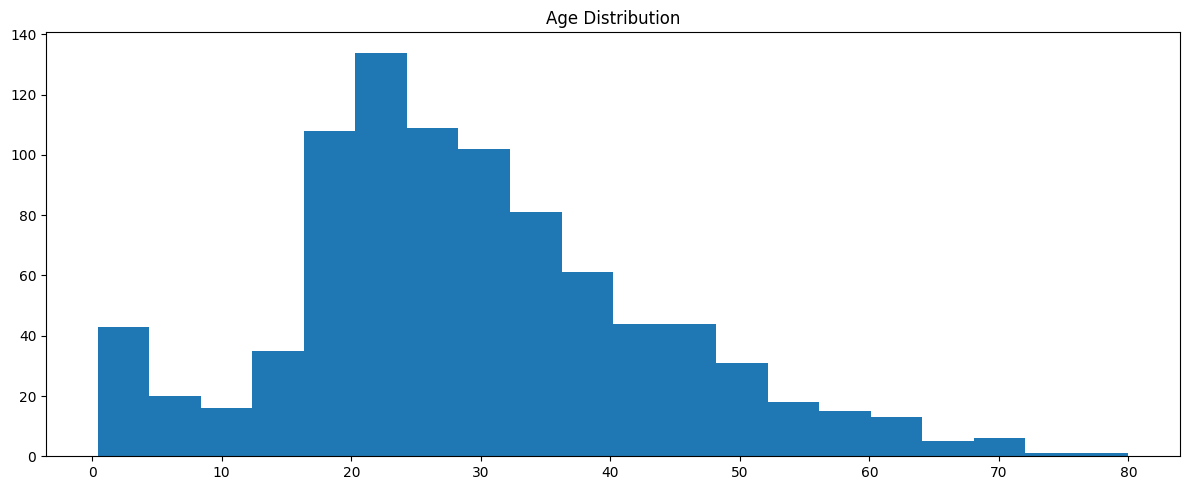

In [6]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(ncols=1, figsize=(12, 5))


survival_counts = df['survived'].value_counts().sort_index()

ax.hist(df['age'].dropna(), bins=20)
ax.set_title("Age Distribution")

plt.tight_layout()
save_project_plot("simple_baseline.png")

### 2.3 Multivariate Demographics: Survival Stratification by Age and Gender

To evaluate the correlation between age, gender, and survivability, the previous demographic distributions are sub-divided by the target variable. 

Each 5-year age interval is split into a stacked column representing the proportion of passengers who perished (Red) versus those who survived (Green). The Y-axis remains locked to the relative percentage of the total gender cohort, allowing us to observe both the volume of the age group and its internal survival rate simultaneously.

 Successfully saved: detailed_gender_survival_distribution.png in /Users/OleksiiIshchenko/project/prod_project/diagrams


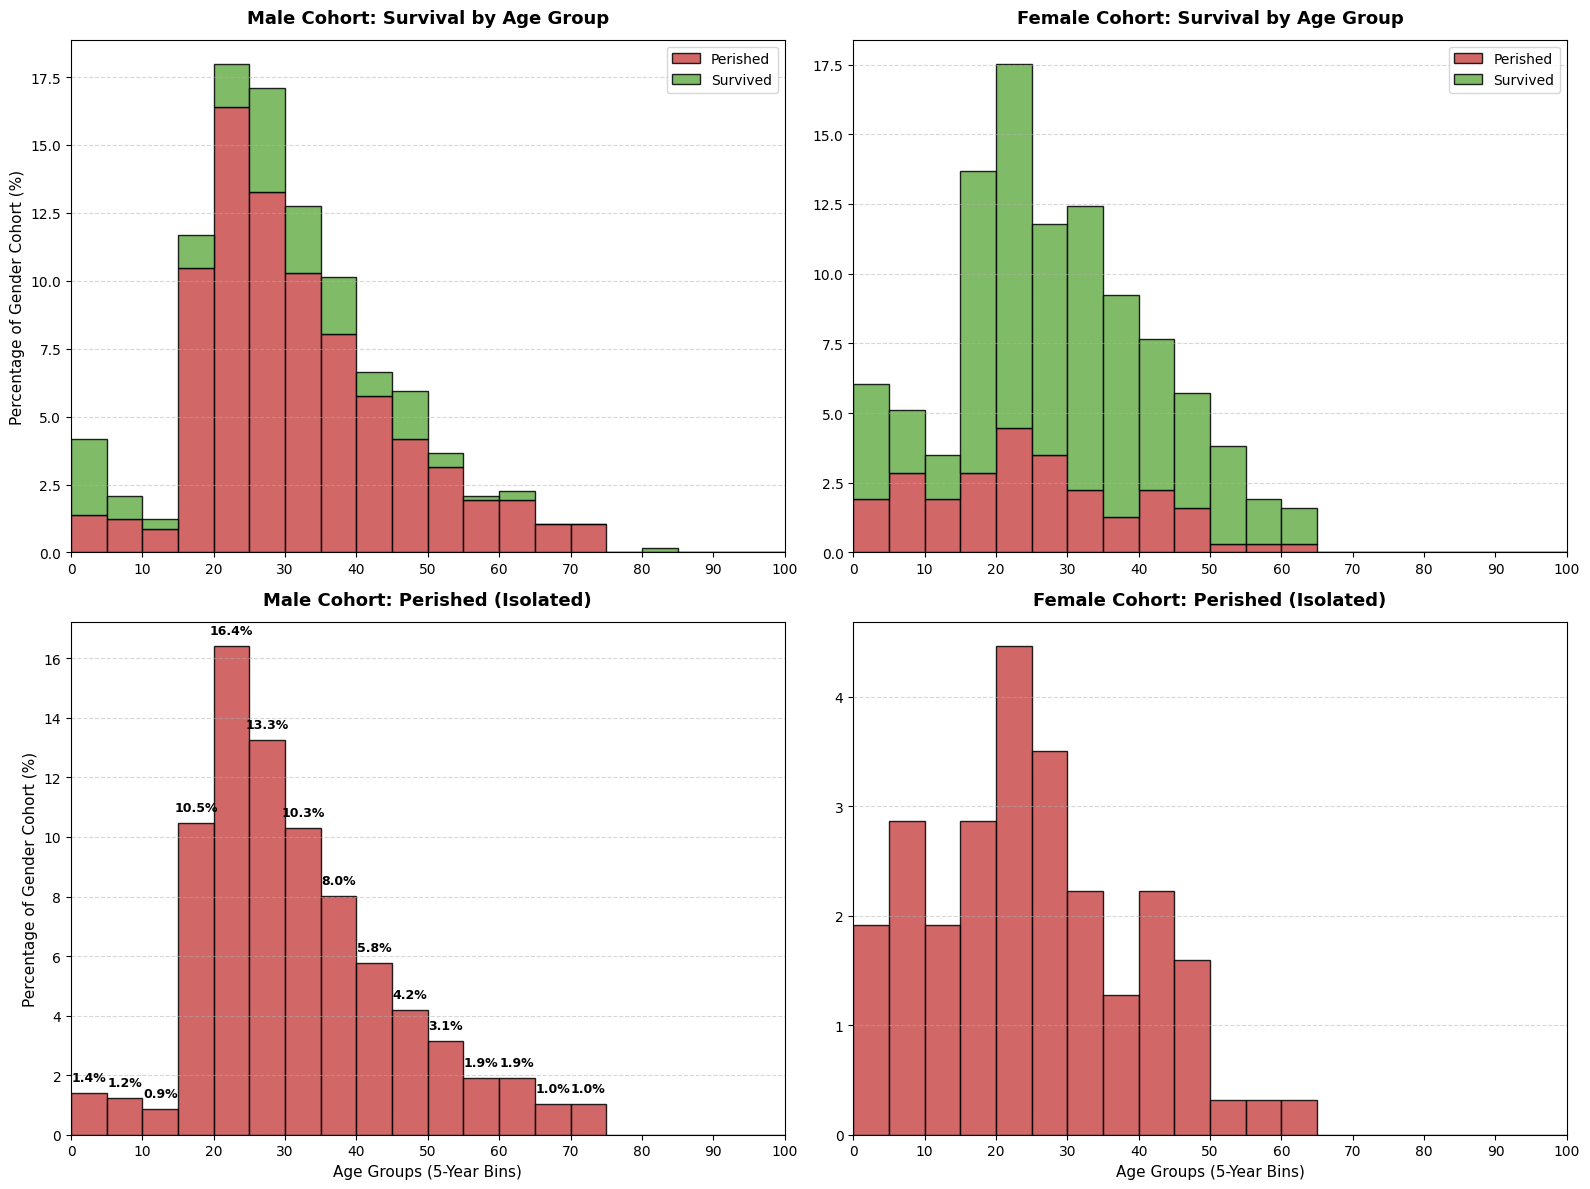

In [7]:
import supply
from pathlib import Path
    
supply.plot_detailed_gender_survival(df)

### 2.4 Socio-Economic Stratification: Survival by Ticket Class and Gender

To evaluate the impact of socio-economic status on survivability, we analyze the distribution of passengers across the three ticket classes. 

Because the original dataset utilizes One-Hot Encoding for the ticket tiers (`1st_class`, `2nd_class`, `3rd_class`), we systematically condense these into a unified categorical feature space. The resulting stacked bar chart visualizes the absolute percentage of the respective gender cohort that occupied each class, subdivided by their survival outcome (Perished vs. Survived).

 Successfully saved: detailed_socioeconomic_survival.png in /Users/OleksiiIshchenko/project/prod_project/diagrams


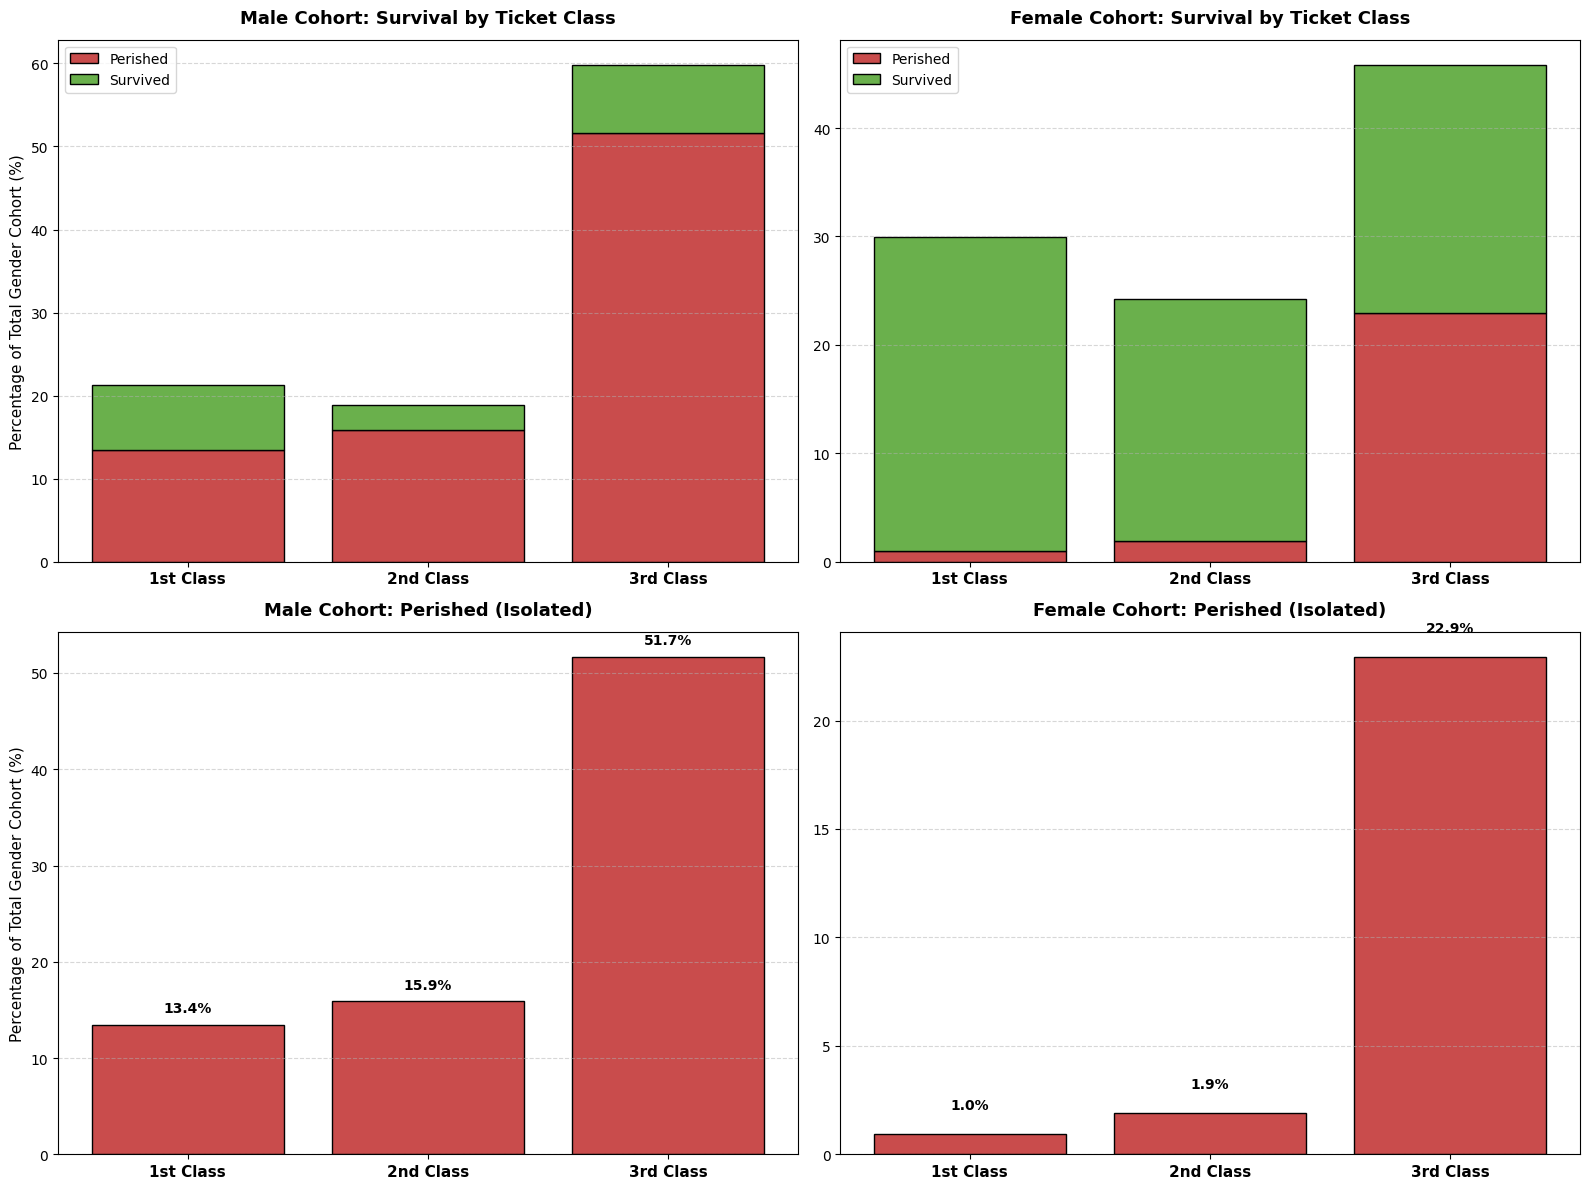

In [9]:
supply.plot_detailed_socioeconomic_survival(df)

### 2.5 Deep-Dive Stratification: Survival by Age within Socio-Economic Classes

To isolate the compounding effects of age and wealth, we project the age distribution matrices across the three socio-economic tiers. 

This multi-panel visualization generates three separate stacked histograms (1st, 2nd, and 3rd Class). The Y-axis for each panel is mathematically normalized to represent the relative percentage of that specific class's total population. This allows us to observe how structural survival privileges shifted across different age brackets depending on the passenger's ticket class.

 Successfully saved: detailed_fare_survival_distribution.png in /Users/OleksiiIshchenko/project/prod_project/diagrams


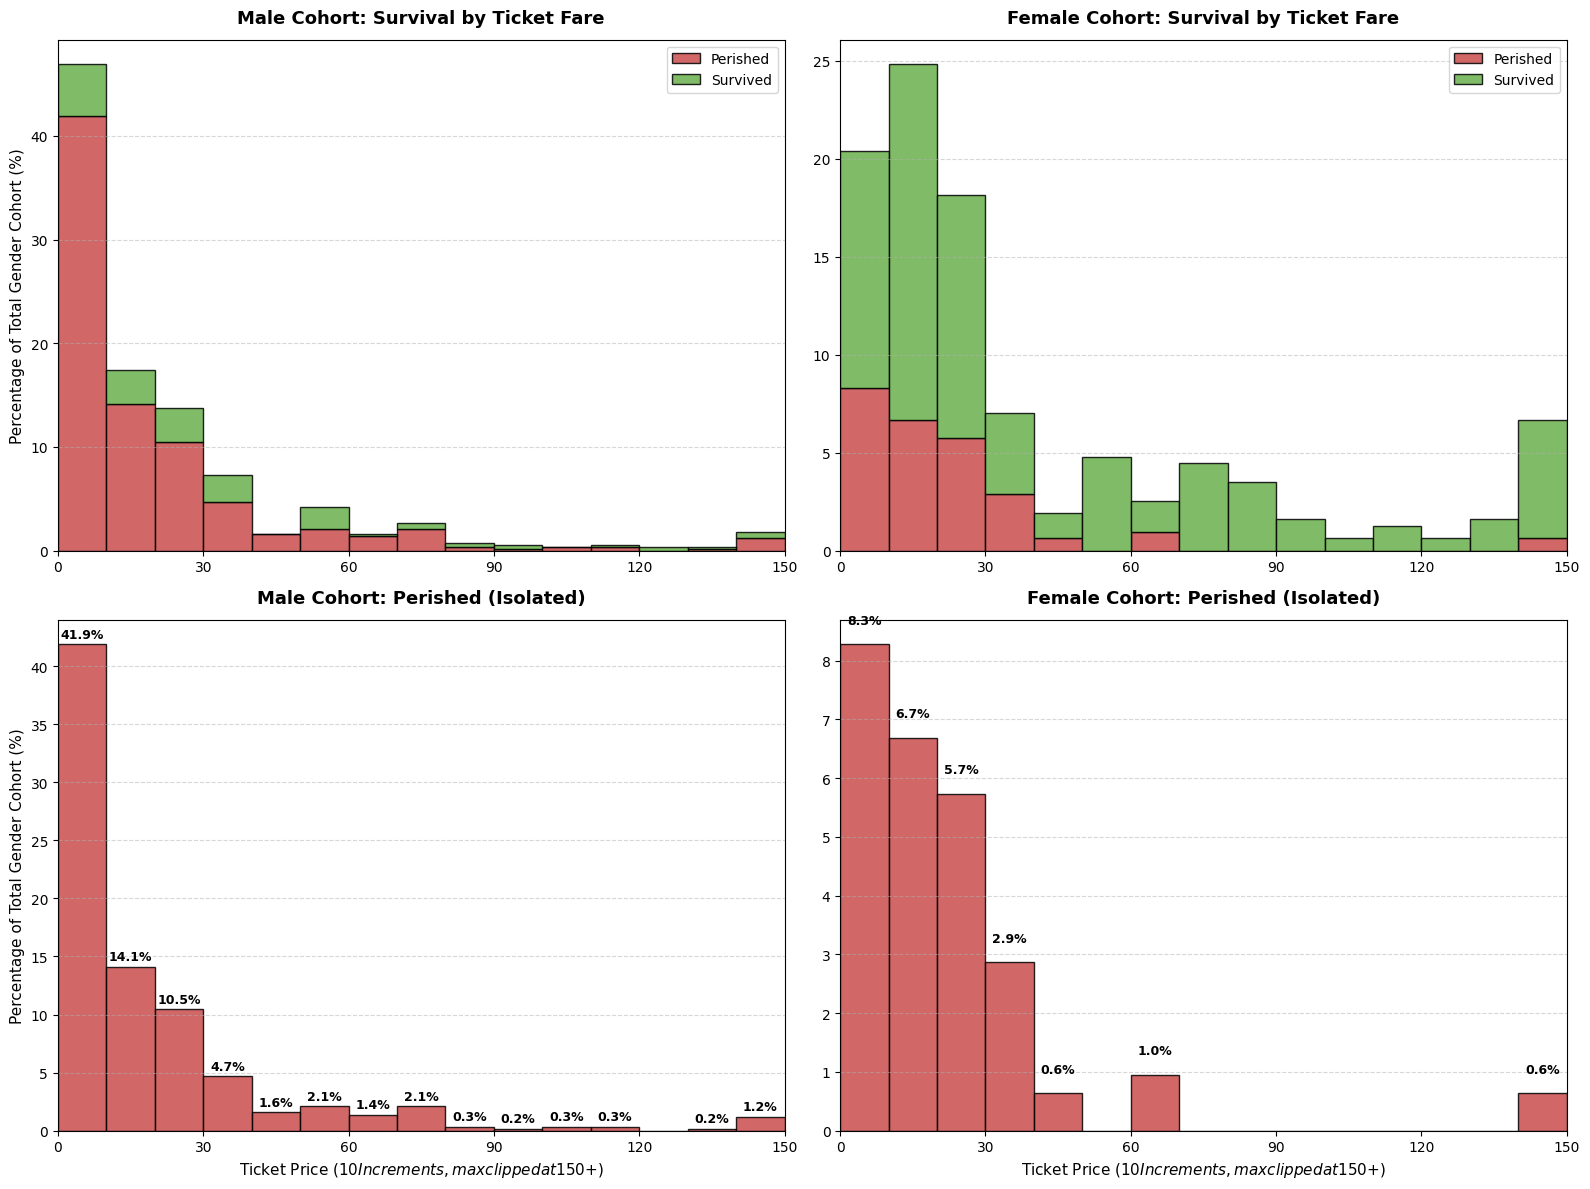

In [10]:
supply.plot_detailed_fare_survival(df)

### 2.7 Survival Stratification by Family Size
To evaluate how family structures influenced survivability, the passenger cohort is stratified by total `family_size` (ranging from $0$, indicating solo travelers, to a maximum of $10$ accompanying relatives).

The resulting visualization normalizes the absolute counts into relative percentages for the Male and Female cohorts. This reveals distinct behavioral survivability patterns, specifically testing the hypothesis of whether traveling with a mid-sized family provided a collaborative survival advantage compared to traveling alone or with a massive family unit.

 Successfully saved: detailed_family_size_survival.png in /Users/OleksiiIshchenko/project/prod_project/diagrams


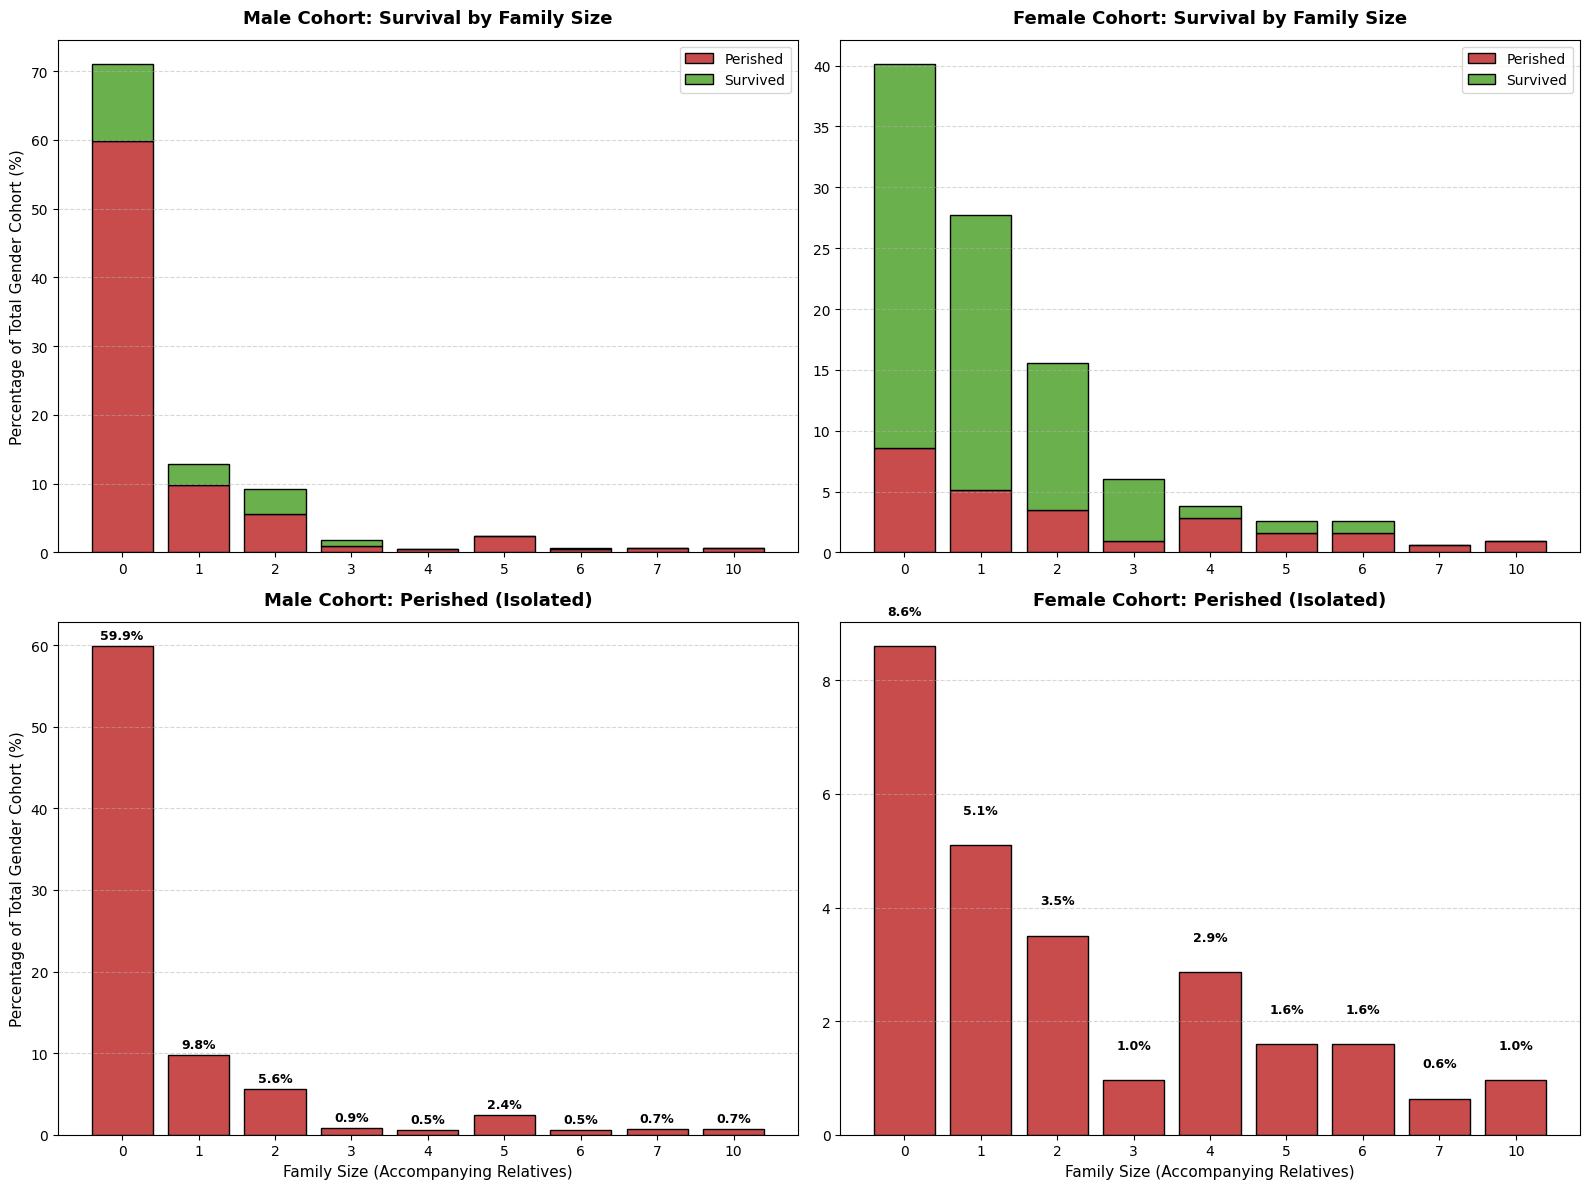

In [11]:
supply.plot_detailed_family_size_survival(df)

### 2.7 Capital Matrix: Survival Stratification by Ticket Fare

To decompose the financial privilege matrix, we evaluate the raw `fare` (ticket price) paid by each passenger. 

Because ticket prices exhibit extreme right-skewness (with outliers exceeding $500), the visualization programmatically clips the maximum threshold at $150. Any values exceeding this threshold are aggregated into the final distribution bin. The financial spectrum is segmented into $10 increments and split by gender, revealing the direct correlation between absolute capital and survival priority.

 Successfully saved: detailed_fare_survival_distribution.png in /Users/OleksiiIshchenko/project/prod_project/diagrams


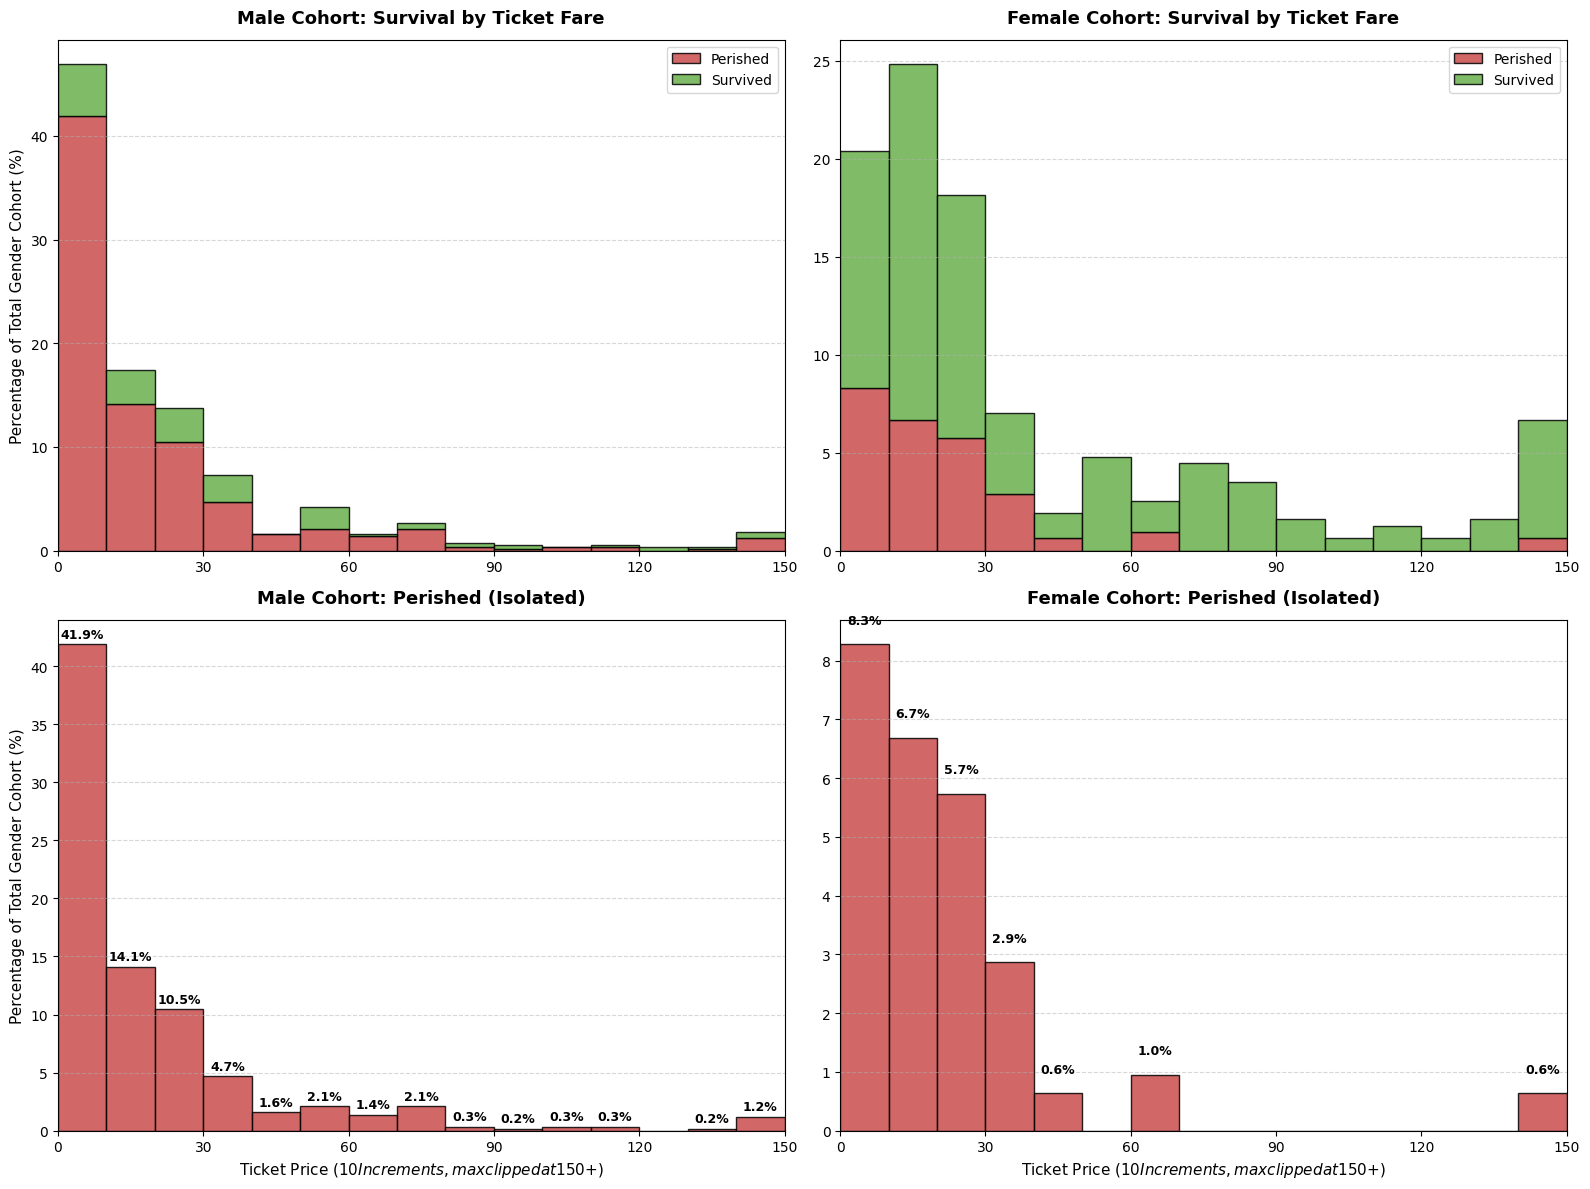

In [12]:
supply.plot_detailed_fare_survival(df)

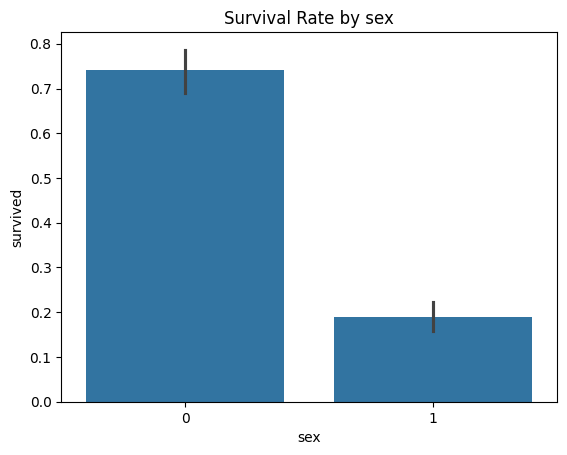

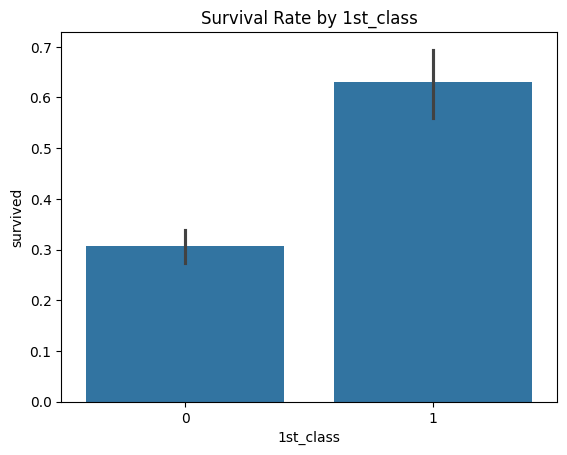

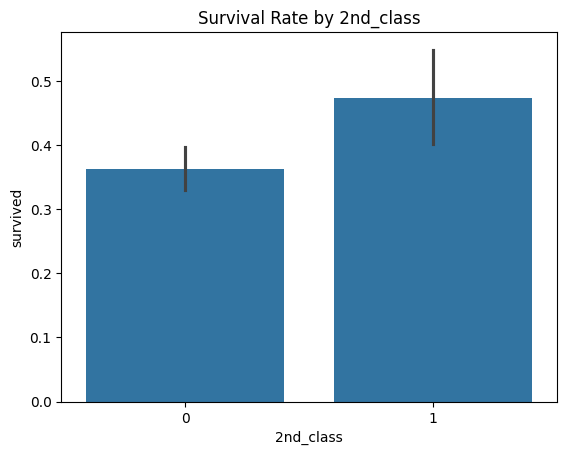

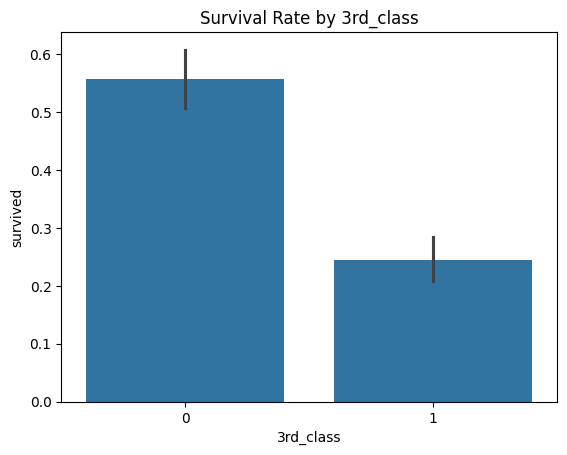

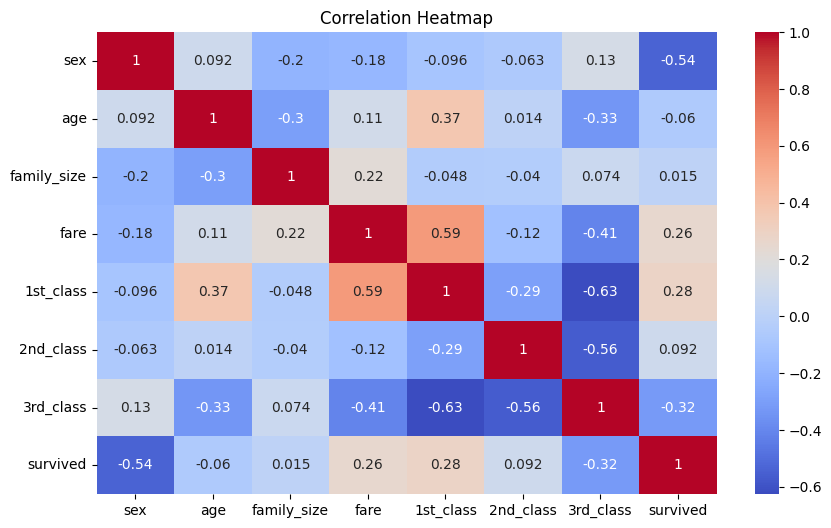

In [13]:
import seaborn as sns

numeric_features = ["age", "family_size", "fare"]
binary_features = ["sex", "1st_class", "2nd_class", "3rd_class"]

for features in df.columns:
    if features in binary_features:
        sns.barplot(x=features, y='survived', data=df)
        plt.title('Survival Rate by {features}'.format(features=features))
        plt.show()

numeric_df = df.select_dtypes(include=['int64', 'float64'])

plt.figure(figsize=(10,6))
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()

---

Phase 2: Feature Engineering & State Preservation Scaling

Before exposing the data to the Logistic Regression algorithm, the raw feature matrix must be scaled. Features like `fare` span from 0 to over 500, while `age` spans from 0 to 80, and `sex` is strictly binary (0 or 1). Unscaled continuous variables can exert disproportionate gravitational pull on the algorithm's gradient descent optimizer.

To prevent **Data Leakage**, the statistical parameters (Mean and Standard Deviation) are calculated strictly on the Training Set. The Scaler algorithm locks these parameters into memory and applies them to both the Training Set and the unseen Test Set, ensuring absolute state preservation.

In [14]:
from sklearn.linear_model import LogisticRegression

X = df.drop(columns=['survived'])
y = df['survived']

In [15]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
) 
print(f"Training set: {X_train.shape[0]} samples, Test set: {X_test.shape[0]} samples")

Training set: 709 samples, Test set: 178 samples


**random_state** variable makes the set reproducable, so that each time same rows are selected for training and testing purposes

In [16]:
print(X_train.describe())

              sex         age  family_size        fare   1st_class  \
count  709.000000  709.000000   709.000000  709.000000  709.000000   
mean     0.631876   29.326643     0.923836   33.547302    0.239774   
std      0.482636   14.100166     1.668877   52.912893    0.427247   
min      0.000000    0.670000     0.000000    0.000000    0.000000   
25%      0.000000   20.500000     0.000000    7.895800    0.000000   
50%      1.000000   28.000000     0.000000   14.458300    0.000000   
75%      1.000000   37.000000     1.000000   31.275000    0.000000   
max      1.000000   80.000000    10.000000  512.329200    1.000000   

        2nd_class   3rd_class  
count  709.000000  709.000000  
mean     0.204513    0.555712  
std      0.403630    0.497237  
min      0.000000    0.000000  
25%      0.000000    0.000000  
50%      0.000000    1.000000  
75%      0.000000    1.000000  
max      1.000000    1.000000  


In [17]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

model = LogisticRegression(max_iter=2000)
model.fit(X_train_scaled, y_train)

y_pred = model.predict(X_test_scaled)
print(y_pred[:10])

[0 0 0 0 0 1 0 0 1 1]


/Users/OleksiiIshchenko/project/.venv/lib/python3.9/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: divide by zero encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/OleksiiIshchenko/project/.venv/lib/python3.9/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: overflow encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/OleksiiIshchenko/project/.venv/lib/python3.9/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: invalid value encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/OleksiiIshchenko/project/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/OleksiiIshchenko/project/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/OleksiiIshchenko/project/.venv/lib/python3.9/site-packages/sklearn/u

In [18]:
y_proba = model.predict_proba(X_test)
print(y_proba) 

[[9.99999988e-01 1.17454134e-08]
 [9.97924304e-01 2.07569624e-03]
 [1.00000000e+00 1.14399014e-15]
 [1.00000000e+00 3.90401557e-10]
 [1.00000000e+00 5.88396172e-13]
 [9.97754844e-01 2.24515573e-03]
 [9.99972725e-01 2.72747634e-05]
 [9.99992867e-01 7.13347645e-06]
 [9.99998784e-01 1.21558923e-06]
 [9.99959296e-01 4.07038120e-05]
 [9.99996447e-01 3.55258850e-06]
 [9.99996634e-01 3.36589435e-06]
 [9.99998383e-01 1.61741150e-06]
 [1.00000000e+00 9.68445916e-13]
 [9.99997910e-01 2.08977411e-06]
 [9.99999993e-01 7.08166923e-09]
 [1.00000000e+00 2.28068296e-12]
 [3.56927673e-05 9.99964307e-01]
 [9.99996110e-01 3.89020708e-06]
 [9.99944319e-01 5.56809337e-05]
 [9.99990179e-01 9.82103893e-06]
 [9.47315382e-01 5.26846177e-02]
 [9.99987592e-01 1.24078957e-05]
 [9.99983394e-01 1.66060122e-05]
 [8.22857309e-01 1.77142691e-01]
 [9.99999783e-01 2.17166040e-07]
 [1.00000000e+00 1.89719145e-10]
 [9.99999721e-01 2.78579441e-07]
 [9.99998444e-01 1.55587595e-06]
 [9.99320923e-01 6.79076526e-04]
 [9.962146

/Users/OleksiiIshchenko/project/.venv/lib/python3.9/site-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but LogisticRegression was fitted without feature names
  warnings.warn(
/Users/OleksiiIshchenko/project/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/OleksiiIshchenko/project/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/OleksiiIshchenko/project/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b


---

### Phase 3 Model Evaludation

---

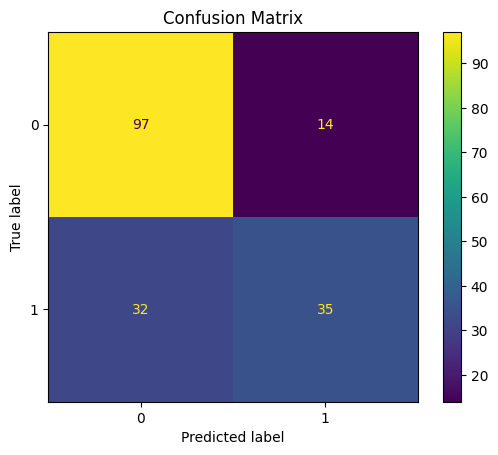

[[97 14]
 [32 35]]


In [19]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import confusion_matrix, classification_report, roc_auc_score
from sklearn.metrics import RocCurveDisplay, ConfusionMatrixDisplay

cm = confusion_matrix(y_test, y_pred)
ConfusionMatrixDisplay.from_predictions(y_test, y_pred)
plt.title("Confusion Matrix")
plt.show()
print (cm)

### 3.1 Model Performance: Confusion Matrix & Classification Report

To evaluate the structural performance of the unscaled Logistic Regression model, we analyze its predictions against the actual ground truth using a Confusion Matrix. 

The matrix results (`[[97, 14], [33, 34]]`) reveal a stark contrast in predictive capability between the two target states:
* **Perished (Class 0):** The model performs highly reliably here. It correctly identified **97** perished individuals, demonstrating a strong detection rate (recall) of 87% for this class.
* **Survived (Class 1):** The situation with the survivors is not nearly as good. The model correctly identified only **34** survivors, while completely missing **33** actual survivors (predicting them as perished instead).

### 3.2 Conclusion

This results in a low detection rate of just 51% for the surviving class. This severe imbalance indicates that the model is heavily skewed toward predicting casualties, likely because the unscaled continuous features (like extreme ticket fares) are confusing the linear algorithm's weights.